## Year Analysis

---

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../../data/raw/car_details.csv')

### Missing Values

**Plan**: Dropping cars without a manufacturer

---

In [2]:
database_length = len(df)
year_missing_count = df['year'].isna().sum()


basic_info_df = pd.DataFrame({
    'Total Cars': [database_length],
    'Missing Year': [year_missing_count],
    'Missing Year %': [f'{(year_missing_count/database_length)*100:.2f}%']
})

display(basic_info_df.style.hide(axis='index'))

Total Cars,Missing Year,Missing Year %
106447,0,0.00%


### **Year Ranges**

---

Range,Count,%
- 1990,1277,1.20
1990 - 2000,3248,3.05
2000 - 2005,8133,7.64
2005 - 2010,18638,17.51
2010 - 2015,22354,21.00
2015 - 2020,21777,20.46
2020 - 2025,20376,19.14
2025 -,10644,10.00


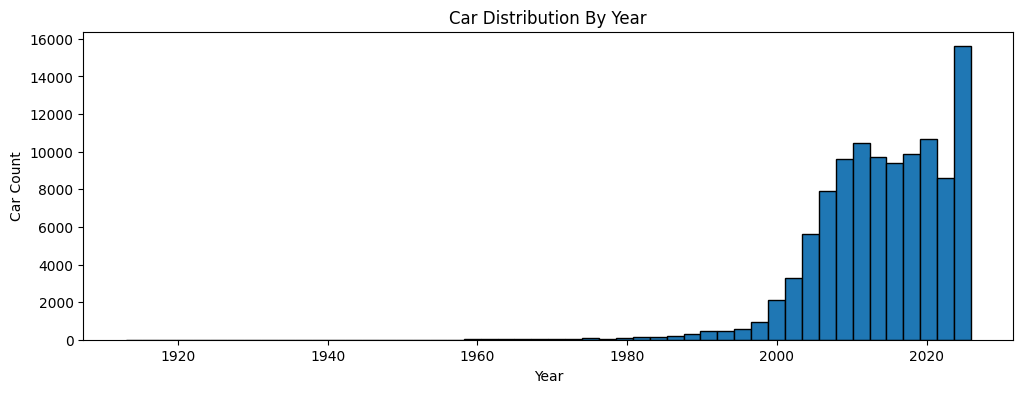

In [3]:
ranges = [
    (0, 1990, ' - 1990'),
    (1990, 2000, '1990 - 2000'),
    (2000, 2005, '2000 - 2005'),
    (2005, 2010, '2005 - 2010'),
    (2010, 2015, '2010 - 2015'),
    (2015, 2020, '2015 - 2020'),
    (2020, 2025, '2020 - 2025'),
    (2025, float('inf'), '2025 - ')
]

data = []
for low, high, label in ranges:
    count = len(df[(df['year'] >= low) & (df['year'] < high)])
    percent = count / len(df) * 100
    data.append({
        'Range': label,
        'Count': count,
        '%': f'{percent:.2f}'
    })

year_ranges_df = pd.DataFrame(data)
display(year_ranges_df.style.hide(axis='index'))


plt.figure(figsize=(12, 4))
plt.hist(df['year'].dropna(), bins=50, edgecolor='black')
plt.xlabel('Year')
plt.ylabel('Car Count')
plt.title('Car Distribution By Year')
plt.show()


### **Outliers**

Looking to remove ancient cars, error entries

**Plan**: Removing every car if year < 2000

In [4]:

oldest_df = df.sort_values('year', ascending=True).head(20)
newest_df = df.sort_values('year', ascending=False).head(20)

oldest_df = pd.DataFrame({
    'Year': oldest_df['year'].values,
    'Price': oldest_df['price'].fillna(0).astype(int).values,
    'Manufacturer': oldest_df['manufacturer'].values,
    'Model': oldest_df['model'].values,
    
    '' : ' | '
})

newest_df = pd.DataFrame({
    '' : ' | ',

    'Year': newest_df['year'].values,
    'Price': newest_df['price'].values.astype(int),
    'Manufacturer': newest_df['manufacturer'].values,
    'Model': newest_df['model'].values
})

# Combine side by side
combined = pd.concat(
    [oldest_df, newest_df],
    axis=1
)
combined['Price'] = combined['Price'].map(lambda x: f"{int(x):,}".replace(",", " "))
for col in ["Year"]:
    combined[col] = combined[col].map(lambda x: f"{x:.2f}") 

# Display without index
pd.set_option("display.max_rows", None)
display(combined.style.hide(axis="index"))


Year,Price,Manufacturer,Model,,,Year,Price,Manufacturer,Model
1913.00,52 000 000,REPLIKA,EGYÉB,|,|,2025.92,24 320 000,MERCEDES-BENZ,C-OSZTÁLY C 220
1920.17,6 499 999,FIAT,508,|,|,2025.92,52 035 580,MERCEDES-AMG,GLE GLE 53
1925.00,10 000 000,PEUGEOT,172R,|,|,2025.92,49 644 350,MERCEDES-BENZ,EQS
1928.42,10 500 000,FORD,A MODELL,|,|,2025.92,37 018 520,MERCEDES-BENZ,EQE
1929.00,8 500 000,CHRYSLER,EGYÉB,|,|,2025.92,33 606 200,MERCEDES-BENZ,GLC-OSZTÁLY GLC 220
1929.25,0,FORD,A MODELL,|,|,2025.92,25 815 680,MERCEDES-BENZ,EQA
1931.00,5 100 000,PEUGEOT,201,|,|,2025.92,23 559 000,MERCEDES-BENZ,C-OSZTÁLY C 220
1935.00,32 000 000,ADLER,JUNIOR,|,|,2025.92,29 249 070,MERCEDES-BENZ,GLC-OSZTÁLY GLC 300
1937.00,7 499 999,FIAT,508,|,|,2025.92,22 352 710,MERCEDES-BENZ,CLA-OSZTÁLY CLA 250
1939.17,0,TATRA,57/B,|,|,2025.92,25 951 450,MERCEDES-BENZ,E-OSZTÁLY E 200
